# EDA

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("housing.csv")
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 1. ¿Cuántas observaciones y cuántas variables tiene el dataset?

In [5]:
n_obs, n_vars = df.shape
print(f"Número de observaciones (filas): {n_obs}")
print(f"Número de variables (columnas): {n_vars}")
df.info()


Número de observaciones (filas): 20640
Número de variables (columnas): 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


**Respuesta:** el dataset contiene **20,640 observaciones** y **10 variables**

### 2. ¿Qué representa cada variable (feature) y cuál es la variable objetivo (target)?

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
longitude,20640.0,NaN,NaN,NaN,-119.569704,2.003532,-124.35,-121.8,-118.49,-118.01,-114.31
latitude,20640.0,NaN,NaN,NaN,35.631861,2.135952,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,NaN,NaN,NaN,28.639486,12.585558,1.0,18.0,29.0,37.0,52.0
total_rooms,20640.0,NaN,NaN,NaN,2635.763081,2181.615252,2.0,1447.75,2127.0,3148.0,39320.0
total_bedrooms,20433.0,NaN,NaN,NaN,537.870553,421.38507,1.0,296.0,435.0,647.0,6445.0
population,20640.0,NaN,NaN,NaN,1425.476744,1132.462122,3.0,787.0,1166.0,1725.0,35682.0
households,20640.0,NaN,NaN,NaN,499.53968,382.329753,1.0,280.0,409.0,605.0,6082.0
median_income,20640.0,NaN,NaN,NaN,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,NaN,NaN,NaN,206855.816909,115395.615874,14999.0,119600.0,179700.0,264725.0,500001.0
ocean_proximity,20640,5,<1H OCEAN,9136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


La variable objetivo, como lo indicaban las instrucciones, es **median_house_value**.

Descripción de las variables:
| Variable | Tipo | Descripción |
|---|---|---|
| `longitude` | Numérica (float) | Coordenada de longitud geográfica del bloque de viviendas (más negativo = más al oeste). |
| `latitude` | Numérica (float) | Coordenada de latitud geográfica del bloque de viviendas (más alto = más al norte). |
| `housing_median_age` | Numérica (float) | Edad mediana de las viviendas dentro del bloque (en años). Un valor menor indica un edificio más nuevo. |
| `total_rooms` | Numérica (float) | Número total de habitaciones dentro de un bloque. |
| `total_bedrooms` | Numérica (float) | Número total de dormitorios dentro de un bloque. |
| `population` | Numérica (float) | Número total de personas que residen dentro de un bloque. |
| `households` | Numérica (float) | Número total de hogares (unidades familiares) que ocupan un bloque de viviendas. |
| `median_income` | Numérica (float) | Ingreso mediano de los hogares dentro de un bloque (en decenas de miles de USD, ya escalado/capado por el proveedor original). |
| `ocean_proximity` | Categórica (object) | Ubicación del bloque respecto al océano. Categorías: `NEAR BAY`, `<1H OCEAN`, `INLAND`, `NEAR OCEAN`, `ISLAND`. |
| **`median_house_value`** | **Numérica (float) — TARGET** | Valor mediano de las viviendas dentro de un bloque (en USD). Es la variable que se busca predecir. |

### 3. ¿Hay valores nulos, duplicados o atípicos (outliers)? ¿Cómo los trató?

In [7]:
#Nulos
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df) * 100).round(2)
pd.DataFrame({"nulos": nulos, "% nulos": porcentaje_nulos}).sort_values("nulos", ascending=False)


,nulos,% nulos
total_bedrooms,207,1.0
longitude,0,0.0
latitude,0,0.0
housing_median_age,0,0.0
total_rooms,0,0.0
population,0,0.0
households,0,0.0
median_income,0,0.0
median_house_value,0,0.0
ocean_proximity,0,0.0


**Hallazgo:** la única columna con valores nulos es `total_bedrooms`. Representa un porcentaje bajo del total de filas, por lo que se puede tratar sin perder información relevante.

**Tratamiento aplicado:** se imputan los valores nulos con la **mediana** de `total_bedrooms` 

In [8]:
mediana_bedrooms = df["total_bedrooms"].median()
df["total_bedrooms"] = df["total_bedrooms"].fillna(mediana_bedrooms)

print(f"Mediana usada para imputar: {mediana_bedrooms}")
print("Nulos restantes en el dataset:")
print(df.isnull().sum().sum())


Mediana usada para imputar: 435.0
Nulos restantes en el dataset:
0


In [9]:
#Duplicados
n_duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas: {n_duplicados}")


Número de filas duplicadas: 0


No se hace nada

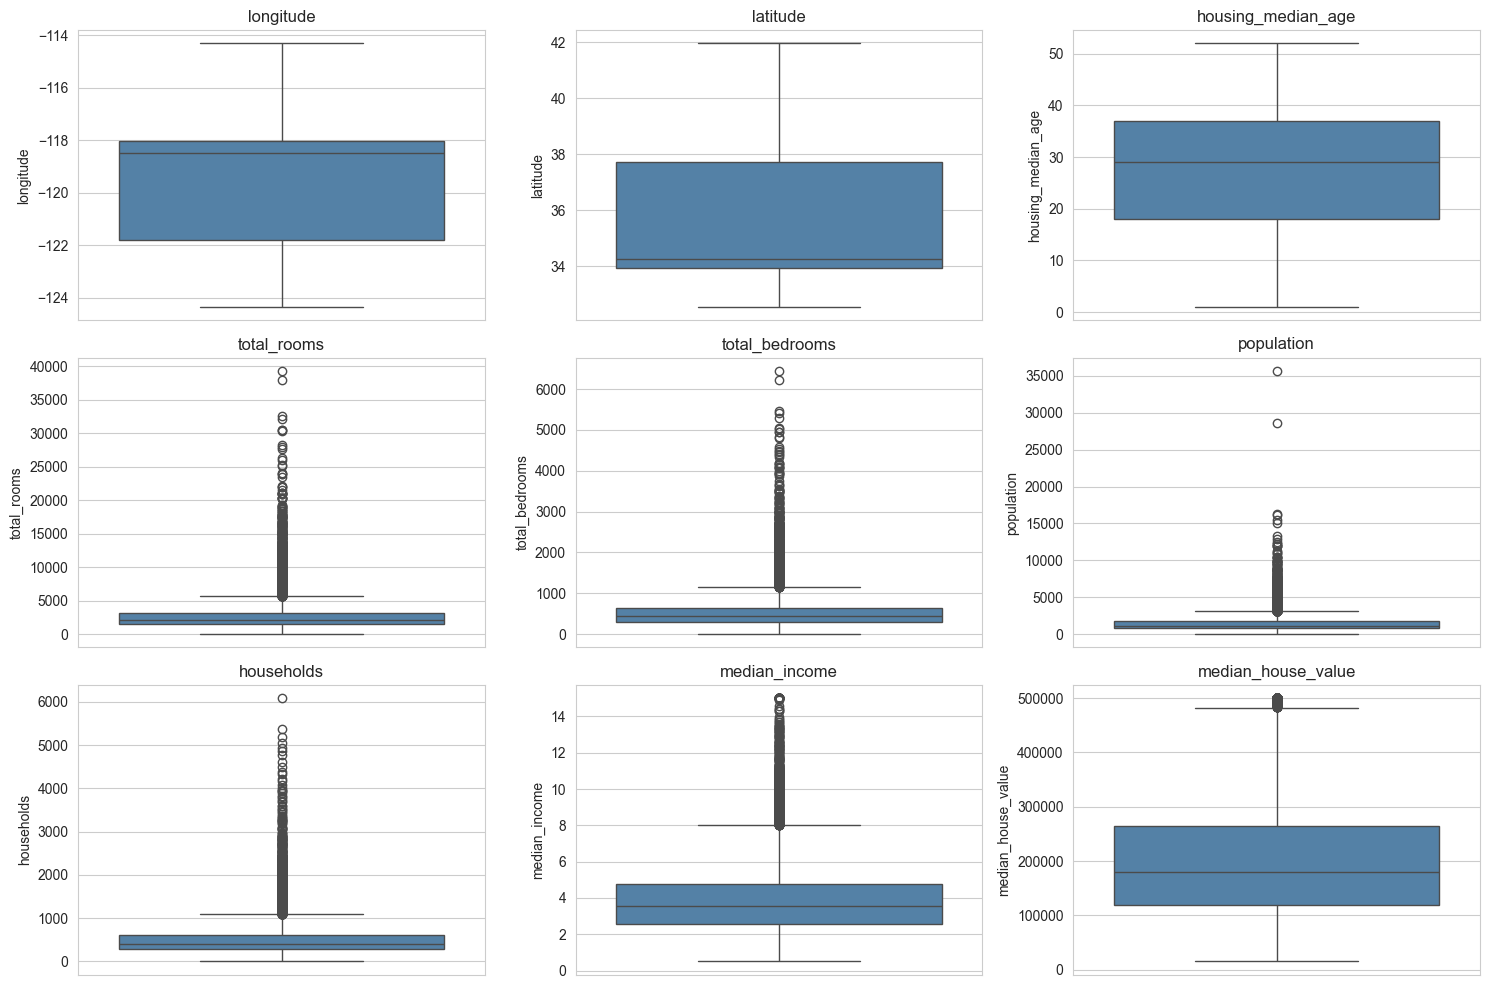

In [10]:
#Outliers
num_cols = ["longitude", "latitude", "housing_median_age", "total_rooms",
            "total_bedrooms", "population", "households", "median_income",
            "median_house_value"]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="steelblue")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


**Hallazgos:**

- Variables como `total_rooms`, `total_bedrooms`, `population`, `households` y `median_income` presentan un número considerable de outliers.
- `median_house_value` muestra un tope claro en 500,000 USD: muchos bloques con valores altos fueron truncados a ese máximo por quien recolectó los datos originalmente.
- `housing_median_age` también parece estar topada en 52 años.

**Tratamiento aplicado:**

- **No se eliminan** los outliers de las variables de conteo (`total_rooms`, `population`, etc.), porque representan bloques censales reales y válidos, no errores de medición. Eliminarlos introduciría sesgo.
- Para el modelo, estos outliers se manejan indirectamente mediante el **escalado** de las variables numéricas, que reduce su impacto en la magnitud de los gradientes sin descartar información.
- Se documenta el *cap* en `median_house_value` (techo en 500,000) como una limitación conocida del dataset; en un análisis más profundo se podría considerar eliminar esas filas topadas si afectan la calidad del modelo de regresión.


### 4. ¿Qué variables son numéricas y cuáles categóricas? ¿Cómo codificó las categóricas?

In [11]:
numericas = df.select_dtypes(include=[np.number]).columns.tolist()
categoricas = df.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:", numericas)
print("Variables categóricas:", categoricas)
print()
print("Categorías únicas en 'ocean_proximity':")
print(df["ocean_proximity"].value_counts())


Variables numéricas: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Variables categóricas: ['ocean_proximity']

Categorías únicas en 'ocean_proximity':
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [12]:
#Codificación aplicada: se usa One-Hot Encoding, que crea una columna binaria por categoría 
df_encoded = pd.get_dummies(df, columns=["ocean_proximity"], prefix="ocean")
df_encoded.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_<1H OCEAN,ocean_INLAND,ocean_ISLAND,ocean_NEAR BAY,ocean_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


In [13]:
print("Columnas antes de codificar:", df.shape[1])
print("Columnas después de One-Hot Encoding:", df_encoded.shape[1])
df_encoded.dtypes


Columnas antes de codificar: 10
Columnas después de One-Hot Encoding: 14


longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_<1H OCEAN          bool
ocean_INLAND             bool
ocean_ISLAND             bool
ocean_NEAR BAY           bool
ocean_NEAR OCEAN         bool
dtype: object

### 5. ¿Fue necesario normalizar o escalar las variables numéricas?

In [14]:
features_numericas = [c for c in numericas if c != "median_house_value"]

scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[features_numericas] = scaler.fit_transform(df_encoded[features_numericas])

df_scaled[features_numericas].describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
longitude,-8.526513e-15,1.000024,-2.385992,2.625280
latitude,-1.079584e-15,1.000024,-1.447568,2.958068
housing_median_age,5.508083e-18,1.000024,-2.196180,1.856182
total_rooms,3.201573e-17,1.000024,-1.207283,16.815580
total_bedrooms,-9.363741e-17,1.000024,-1.277688,14.087789
population,-1.101617e-17,1.000024,-1.256123,30.250330
households,6.885104e-17,1.000024,-1.303984,14.601520
median_income,6.609700e-17,1.000024,-1.774299,5.858286


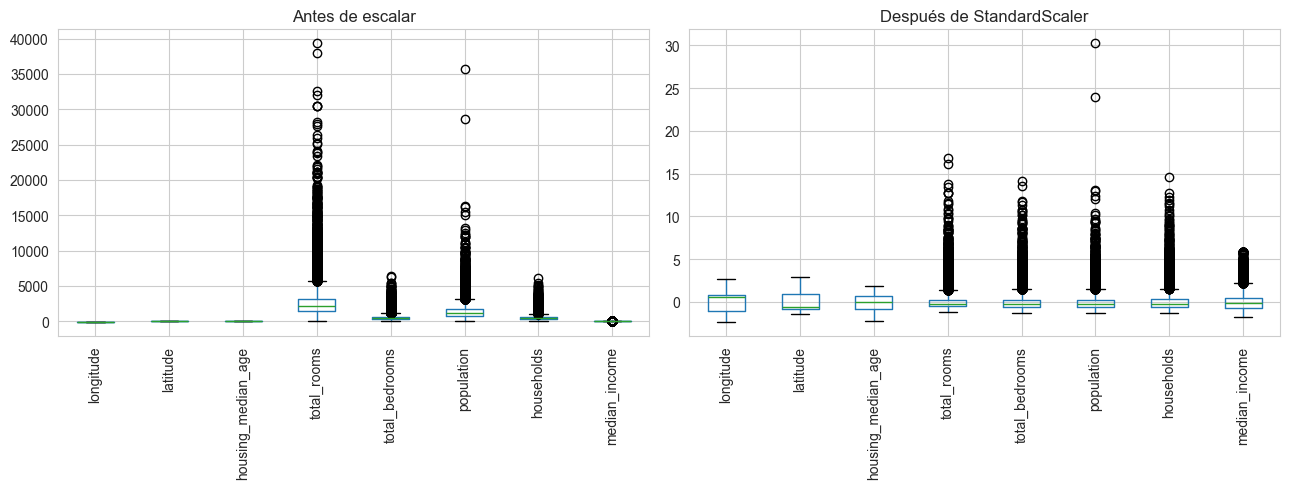

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df[features_numericas].boxplot(ax=axes[0], rot=90)
axes[0].set_title("Antes de escalar")

df_scaled[features_numericas].boxplot(ax=axes[1], rot=90)
axes[1].set_title("Después de StandardScaler")

plt.tight_layout()
plt.show()


Sí, fue necesario escalar las variables numéricas, por dos razones principales:

1. **Diferencias de escala muy grandes:** Para una red neuronal, estas diferencias de magnitud hacen que el descenso de gradiente converja lento o de forma inestable, ya que las variables con valores más grandes dominan el cálculo del error/gradiente.
2. **Sensibilidad de las redes neuronales a la escala de entrada:** funciones de activación (sigmoid, tanh) y la inicialización de pesos asumen entradas en rangos similares y acotados.

Se aplica **`StandardScaler`** (estandarización: media 0, desviación estándar 1) a las variables numéricas *features* (excluyendo el target, que normalmente se escala aparte o se deja en su escala original según la función de pérdida usada).

## Train y Test

In [16]:
from sklearn.model_selection import train_test_split

# Separar features (X) y target (y)
X = df_encoded.drop(columns=["median_house_value"])
y = df_encoded["median_house_value"]

# 1) Primero se separa el TEST y se deja completamente aparte.
#    A partir de aquí, X_test/y_test no se vuelven a tocar hasta la evaluación final
#    (no se usan para ajustar hiperparámetros, ni para fit del scaler/encoder).
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# 2) Del resto (train_val) se separa VALIDATION, que sí se usa para tuning de hiperparámetros.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42
)  # 0.1765 * 0.85 ≈ 0.15  -> proporciones finales: ~70% train / ~15% val / ~15% test

print(f"Train: {X_train.shape[0]} obs ({X_train.shape[0]/len(df_encoded)*100:.1f}%)")
print(f"Val:   {X_val.shape[0]} obs ({X_val.shape[0]/len(df_encoded)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} obs ({X_test.shape[0]/len(df_encoded)*100:.1f}%)")

# 3) IMPORTANTE: el escalado (StandardScaler) debe ajustarse (fit) SOLO con train,
#    y luego aplicarse (transform) a val y test. Nunca hacer fit con datos de test.
scaler = StandardScaler()
X_train[features_numericas] = scaler.fit_transform(X_train[features_numericas])
X_val[features_numericas]   = scaler.transform(X_val[features_numericas])
X_test[features_numericas]  = scaler.transform(X_test[features_numericas])

Train: 14447 obs (70.0%)
Val:   3097 obs (15.0%)
Test:  3096 obs (15.0%)


In [17]:
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)